# Pooling Layer
---
In this notebook, we add and visualize the output of a maxpooling layer in a CNN.

### Import the image

In [7]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
IMG = '../../../img'

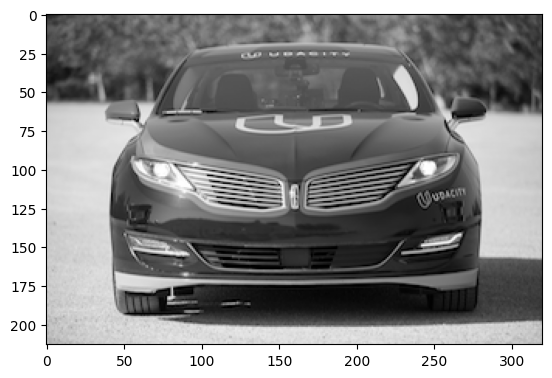

In [3]:
img_path = f'{IMG}/udacity_sdc.png'
bgr_img = cv2.imread(img_path)
gray_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2GRAY)
gray_img = gray_img.astype("float32") / 255

plt.imshow(gray_img, cmap='gray');

### Define and visualize the filters

In [5]:
filter_vals = np.array([
    [-1, -1, 1, 1], 
    [-1, -1, 1, 1], 
    [-1, -1, 1, 1], 
    [-1, -1, 1, 1]])
print('Filter shape: ', filter_vals.shape)

Filter shape:  (4, 4)


In [6]:
# Defining four different filters, 
# all of which are linear combinations of the `filter_vals` defined above
# define four filters
filter_1 = filter_vals
filter_2 = -filter_1
filter_3 = filter_1.T
filter_4 = -filter_3
filters = np.array([filter_1, filter_2, filter_3, filter_4])

print('Filter 1: \n', filter_1)

Filter 1: 
 [[-1 -1  1  1]
 [-1 -1  1  1]
 [-1 -1  1  1]
 [-1 -1  1  1]]


### Define convolutional and pooling layers

Initialize a convolutional layer so that it contains all your created filters. Then add a maxpooling layer, [documented here](https://pytorch.org/docs/stable/nn.html#maxpool2d), with a kernel size of (4x4) so you can really see that the image resolution has been reduced after this step!

In [8]:
# define a neural network with a convolutional layer with four filters
# AND a pooling layer of size (4, 4)
class Net(nn.Module):    
    def __init__(self, weight):
        super().__init__()
        # initializes the weights of the convolutional layer to be the weights of the 4 defined filters
        k_height, k_width = weight.shape[2:]
        # assumes there are 4 grayscale filters
        self.conv = nn.Conv2d(1, 4, kernel_size=(k_height, k_width), bias=False)
        self.conv.weight = torch.nn.Parameter(weight)
        self.pool = nn.MaxPool2d(4, 4)

    def forward(self, x):
        conv_x = self.conv(x)
        activated_x = F.relu(conv_x)
        pooled_x = self.pool(activated_x)
        return conv_x, activated_x, pooled_x

In [9]:
weight = torch.from_numpy(filters).unsqueeze(1).type(torch.FloatTensor)
model = Net(weight)
print(model)

Net(
  (conv): Conv2d(1, 4, kernel_size=(4, 4), stride=(1, 1), bias=False)
  (pool): MaxPool2d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
)


### Visualize the output of each filter

First, we'll define a helper function, `viz_layer` that takes in a specific layer and number of filters (optional argument), and displays the output of that layer once an image has been passed through.

In [10]:
def viz_layer(layer, n_filters= 4):
    fig = plt.figure(figsize=(20, 20))    
    for i in range(n_filters):
        ax = fig.add_subplot(1, n_filters, i + 1, xticks=[], yticks=[])
        ax.imshow(np.squeeze(layer[0,i].data.numpy()), cmap='gray')
        ax.set_title('Output %s' % str(i+1))

Let's look at the output of a convolutional layer after a ReLu activation function is applied.

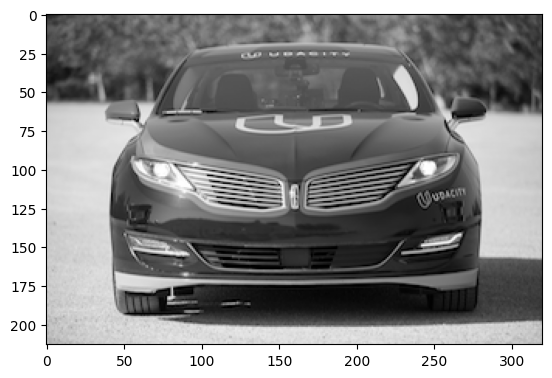

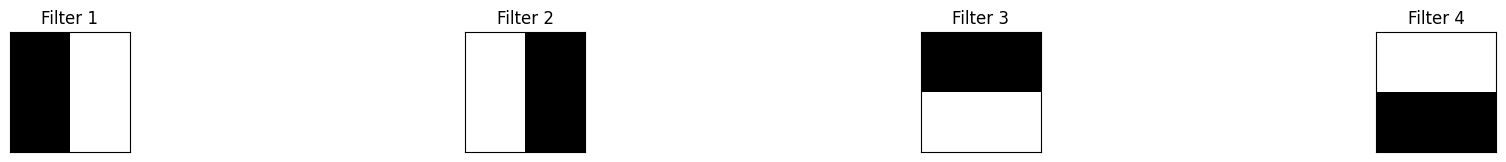

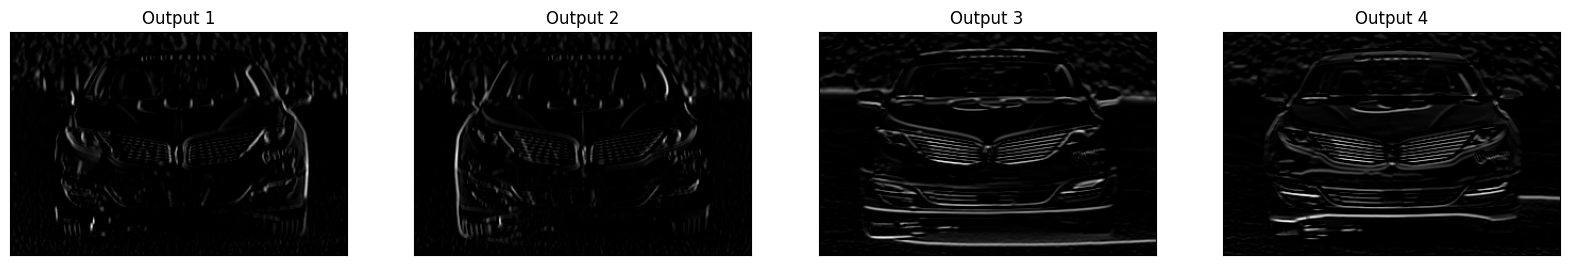

In [11]:
plt.imshow(gray_img, cmap='gray')

# visualize all filters
fig = plt.figure(figsize=(12, 6))
fig.subplots_adjust(left=0, right=1.5, bottom=0.8, top=1, hspace=0.05, wspace=0.05)
for i in range(4):
    ax = fig.add_subplot(1, 4, i + 1, xticks=[], yticks=[])
    ax.imshow(filters[i], cmap='gray')
    ax.set_title(f'Filter {i + 1}')
    
# convert the image into an input Tensor
gray_img_tensor = torch.from_numpy(gray_img).unsqueeze(0).unsqueeze(1)
conv_layer, activated_layer, pooled_layer = model(gray_img_tensor)
viz_layer(activated_layer)

### Visualize the output of the pooling layer

Then, take a look at the output of a pooling layer. The pooling layer takes as input the feature maps pictured above and reduces the dimensionality of those maps, by some pooling factor, by constructing a new, smaller image of only the maximum (brightest) values in a given kernel area.



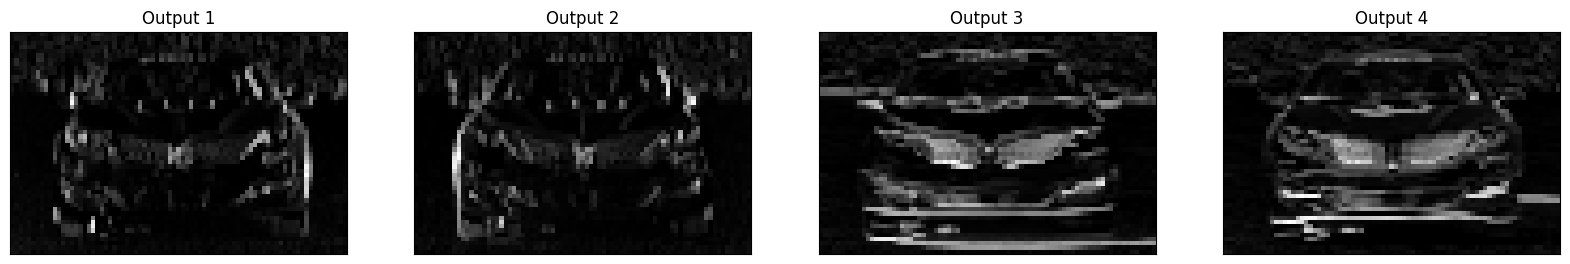

In [12]:
# visualize the output of the pooling layer
viz_layer(pooled_layer)